# Bank Customer Churn Dataset - Data Preprocessing

This notebook adapts the preprocessing workflow to your **Bank Customer Churn Prediction** project using `Churn_Modelling.csv`.

**Goal:** clean the dataset, remove irrelevant columns, handle duplicates, inspect outliers, encode categorical features, scale numeric features, and save a processed dataset for model training.


In [1]:
import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style("whitegrid")

In [2]:
from pathlib import Path

BASE_DIR = Path("..").resolve()
FIGURES_DIR = BASE_DIR / "outputs" / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

FIGURES_DIR

WindowsPath('D:/work/Year - 4/lec/ML/assignment/bank_customer_churn_prediction-ml/outputs/figures')

## Load Dataset

In [3]:
DATA_PATH = BASE_DIR / "data" / "raw" / "Churn_Modelling.csv"

df = pd.read_csv(DATA_PATH)
df.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Basic Information

In [4]:
print("Shape of dataset:", df.shape)
display(df.head())
display(df.describe(include='all'))
df.info()

Shape of dataset: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
unique,NaN,NaN,2932,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Smith,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,32,NaN,5014,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5000.50000,1.569094e+07,NaN,650.528800,NaN,NaN,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,NaN,96.653299,NaN,NaN,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,NaN,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,NaN,584.000000,NaN,NaN,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,NaN,652.000000,NaN,NaN,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,NaN,718.000000,NaN,NaN,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


## Check Missing Values

In [5]:
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

print("Missing values per column:")
display(missing_values)

print("Missing percentage per column:")
display(missing_percent)

Missing values per column:


RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Missing percentage per column:


RowNumber          0.0
CustomerId         0.0
Surname            0.0
CreditScore        0.0
Geography          0.0
Gender             0.0
Age                0.0
Tenure             0.0
Balance            0.0
NumOfProducts      0.0
HasCrCard          0.0
IsActiveMember     0.0
EstimatedSalary    0.0
Exited             0.0
dtype: float64

## Check Duplicate Rows

This dataset usually does not contain duplicate rows, but we verify it before moving forward.


In [6]:
print("Duplicate rows before removal:", df.duplicated().sum())

df = df.drop_duplicates()

print("Shape after duplicate removal:", df.shape)
print("Duplicate rows after removal:", df.duplicated().sum())

Duplicate rows before removal: 0
Shape after duplicate removal: (10000, 14)
Duplicate rows after removal: 0


## Drop Irrelevant Columns

The following columns are not useful for prediction:
- `RowNumber` -> row index only
- `CustomerId` -> unique identifier
- `Surname` -> customer name, not a stable predictive feature for this project


In [7]:
columns_to_drop = ['RowNumber', 'CustomerId', 'Surname']
df = df.drop(columns=columns_to_drop)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Identify Numerical and Categorical Columns

In [8]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical columns:", numerical_columns)
print("Categorical columns:", categorical_columns)

Numerical columns: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
Categorical columns: ['Geography', 'Gender']


C:\Users\thara\AppData\Local\Temp\ipykernel_12412\2868315336.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object']).columns.tolist()


## Target Variable Distribution

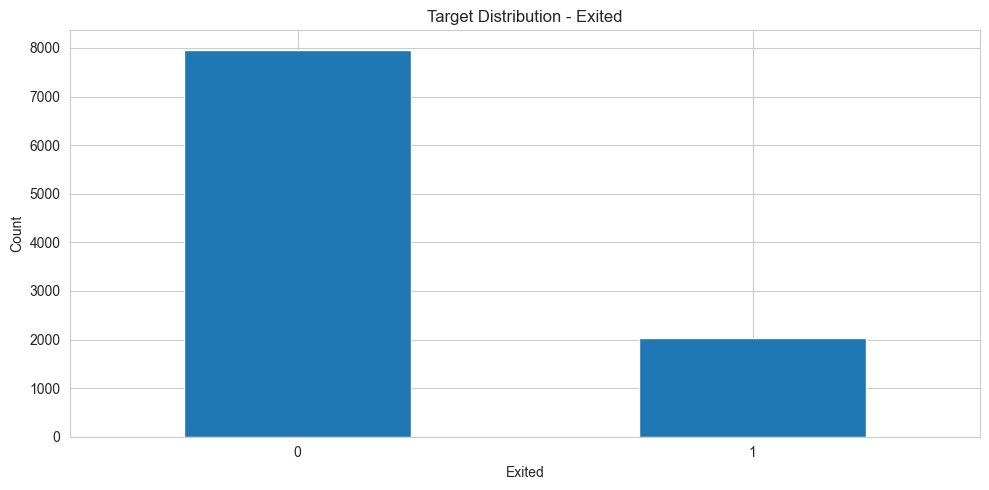

Exited
0    7963
1    2037
Name: count, dtype: int64
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


In [9]:
df['Exited'].value_counts().sort_index().plot(kind='bar')
plt.title('Target Distribution - Exited')
plt.xlabel('Exited')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "class_distribution.png")

plt.show()

print(df['Exited'].value_counts())
print(df['Exited'].value_counts(normalize=True) * 100)

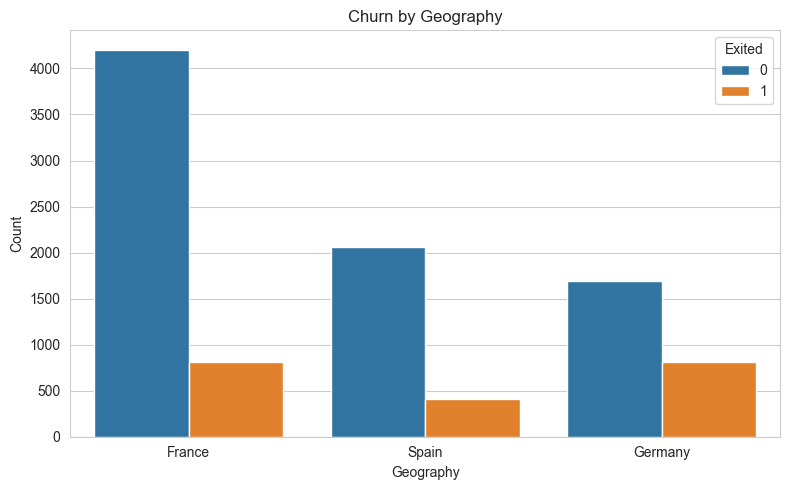

In [10]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Geography', hue='Exited')
plt.title('Churn by Geography')
plt.xlabel('Geography')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "churn_by_geography.png")
plt.show()



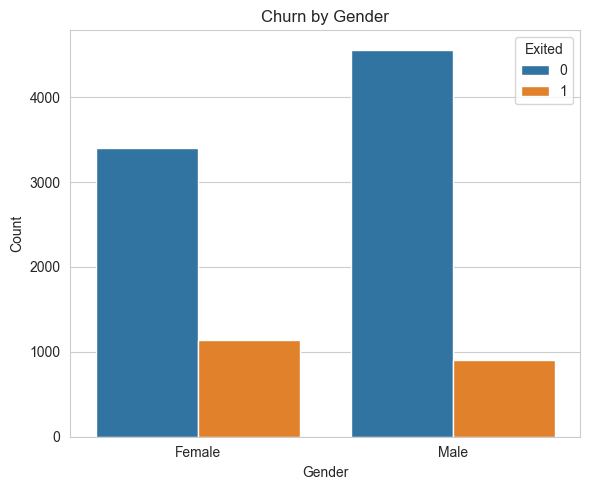

In [11]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='Gender', hue='Exited')
plt.title('Churn by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "churn_by_gender.png")
plt.show()



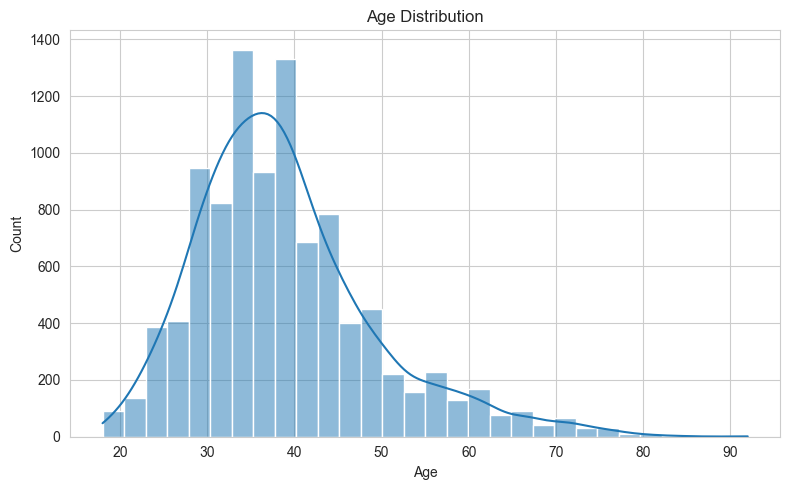

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Age', kde=True, bins=30)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "age_distribution.png")
plt.show()



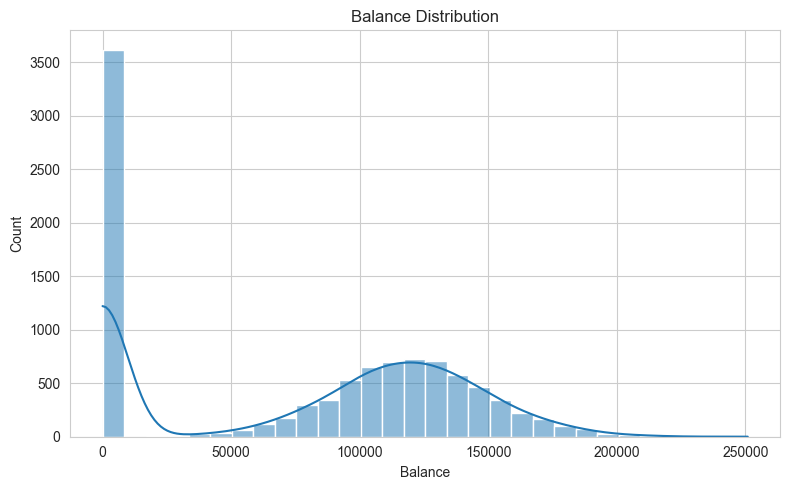

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Balance', kde=True, bins=30)
plt.title('Balance Distribution')
plt.xlabel('Balance')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "balance_distribution.png")
plt.show()



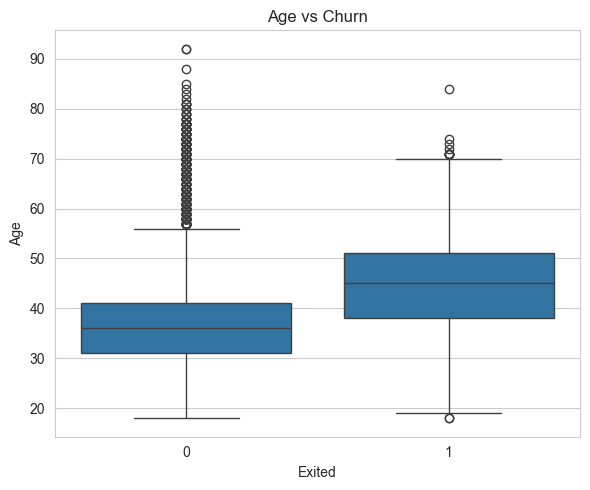

In [14]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x='Exited', y='Age')
plt.title('Age vs Churn')
plt.xlabel('Exited')
plt.ylabel('Age')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "age_vs_churn_boxplot.png")
plt.show()



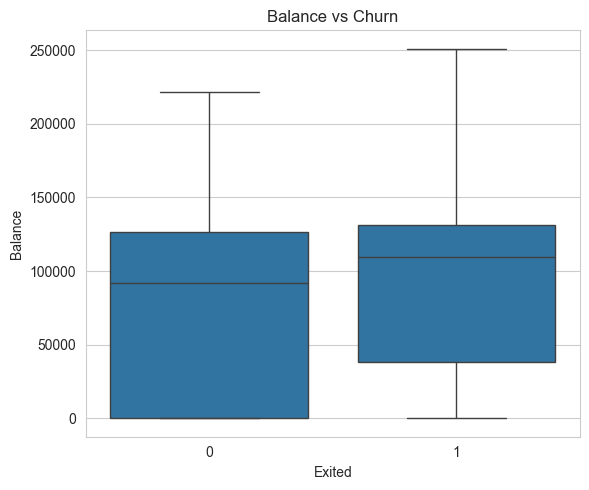

In [15]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x='Exited', y='Balance')
plt.title('Balance vs Churn')
plt.xlabel('Exited')
plt.ylabel('Balance')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "balance_vs_churn_boxplot.png")
plt.show()



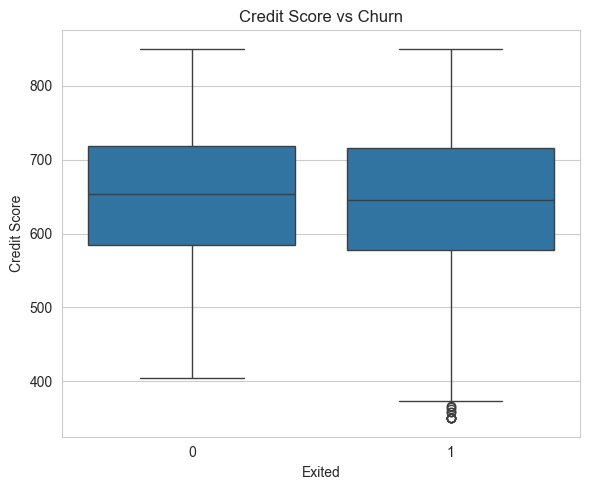

In [16]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x='Exited', y='CreditScore')
plt.title('Credit Score vs Churn')
plt.xlabel('Exited')
plt.ylabel('Credit Score')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "creditscore_vs_churn_boxplot.png")
plt.show()



## Inspect Categorical Columns

In [17]:
for col in categorical_columns:
    print(f"\nColumn: {col}")
    display(df[col].value_counts())


Column: Geography


Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64


Column: Gender


Gender
Male      5457
Female    4543
Name: count, dtype: int64

## Visualize Outliers with Boxplots

We inspect outliers in numeric features.  
For churn prediction, columns such as `Age`, `CreditScore`, and `NumOfProducts` may show extreme values.


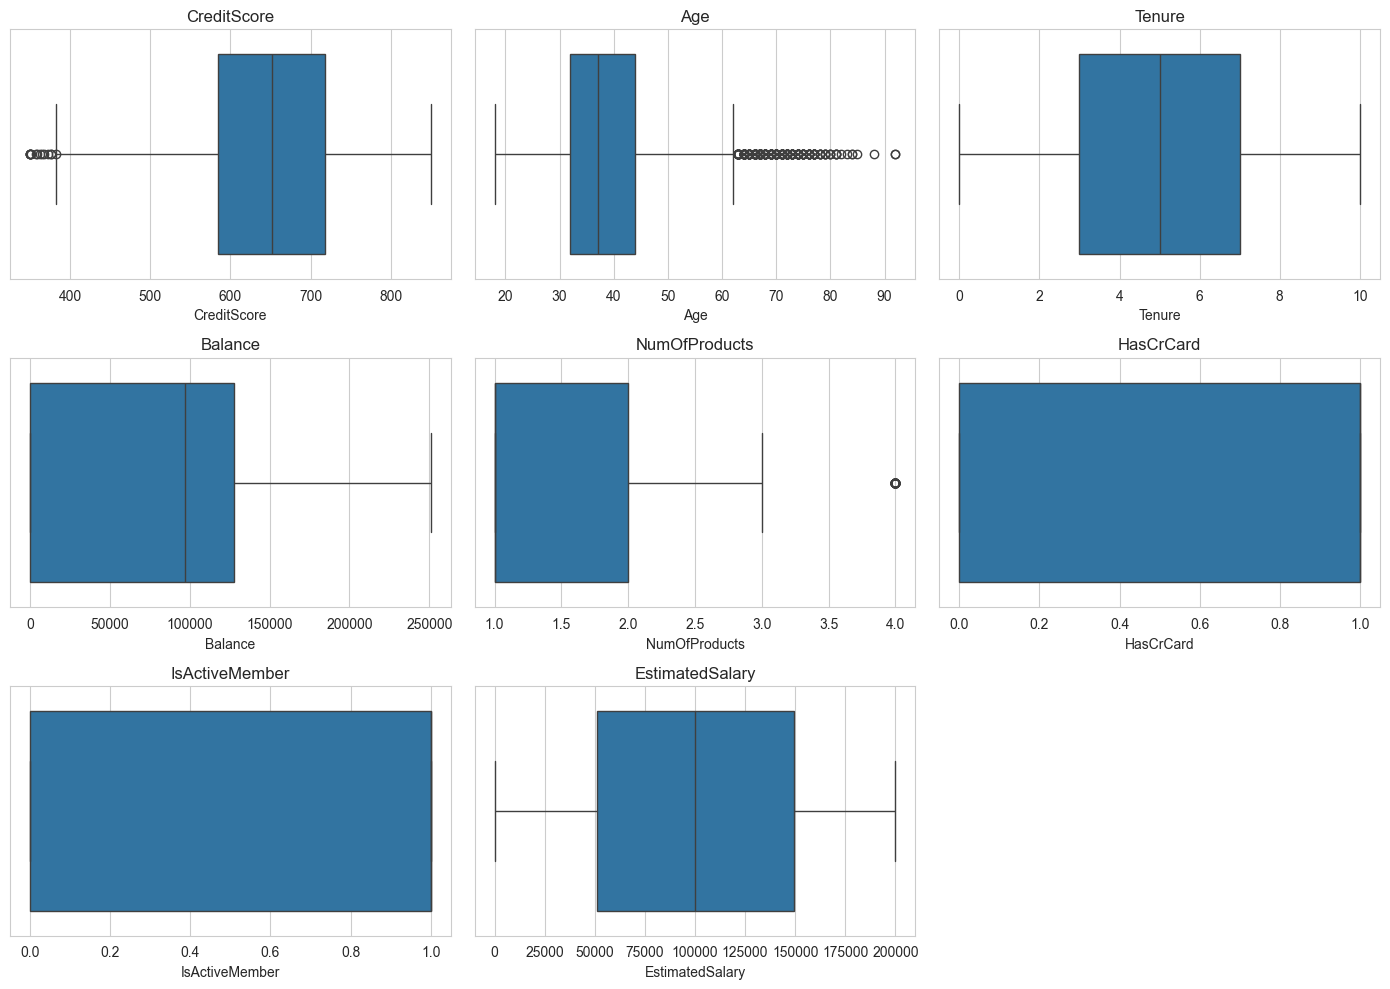

In [18]:
feature_columns_for_boxplot = [col for col in numerical_columns if col != 'Exited']

plt.figure(figsize=(14, 10))
for i, col in enumerate(feature_columns_for_boxplot, 1):
    plt.subplot((len(feature_columns_for_boxplot) // 3) + 1, 3, i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()

plt.savefig(FIGURES_DIR / "numerical_boxplots.png")

plt.show()

## Handle Outliers Using IQR Capping

We cap extreme values instead of removing rows, so we do not lose useful customer records.


In [19]:
def outlier_handler_iqr(dataframe, column):
    q1 = dataframe[column].quantile(0.25)
    q3 = dataframe[column].quantile(0.75)
    iqr = q3 - q1
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    outlier_count = ((dataframe[column] < lower_limit) | (dataframe[column] > upper_limit)).sum()
    dataframe[column] = dataframe[column].clip(lower=lower_limit, upper=upper_limit)

    return outlier_count, lower_limit, upper_limit

outlier_summary = []

for col in ['CreditScore', 'Age', 'NumOfProducts']:
    count, lower, upper = outlier_handler_iqr(df, col)
    outlier_summary.append([col, count, lower, upper])

outlier_summary_df = pd.DataFrame(outlier_summary, columns=['Column', 'Outlier Count', 'Lower Limit', 'Upper Limit'])
outlier_summary_df

,Column,Outlier Count,Lower Limit,Upper Limit
0,CreditScore,15,383.0,919.0
1,Age,359,14.0,62.0
2,NumOfProducts,60,-0.5,3.5


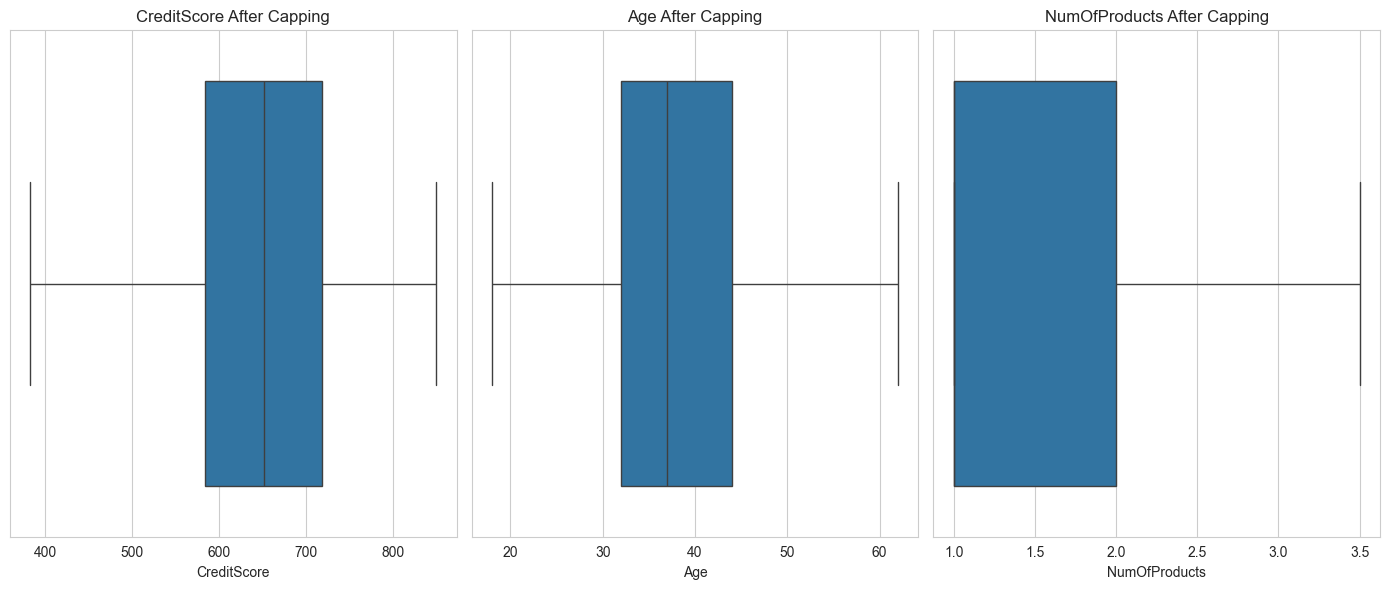

In [20]:
plt.figure(figsize=(14, 6))
for i, col in enumerate(['CreditScore', 'Age', 'NumOfProducts'], 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x=df[col])
    plt.title(f'{col} After Capping')

plt.tight_layout()

plt.savefig(FIGURES_DIR / "capped_boxplots.png")

plt.show()

## Encode Categorical Features

In [21]:
# Gender -> Binary Encoding
gender_encoder = LabelEncoder()
df['Gender'] = gender_encoder.fit_transform(df['Gender'])   # Female/Male -> 0/1

# Geography -> One-Hot Encoding
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1.0,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1.0,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3.0,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2.0,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1.0,1,1,79084.10,0,False,True


## Correlation Analysis

This helps identify which features are positively or negatively related to customer churn.


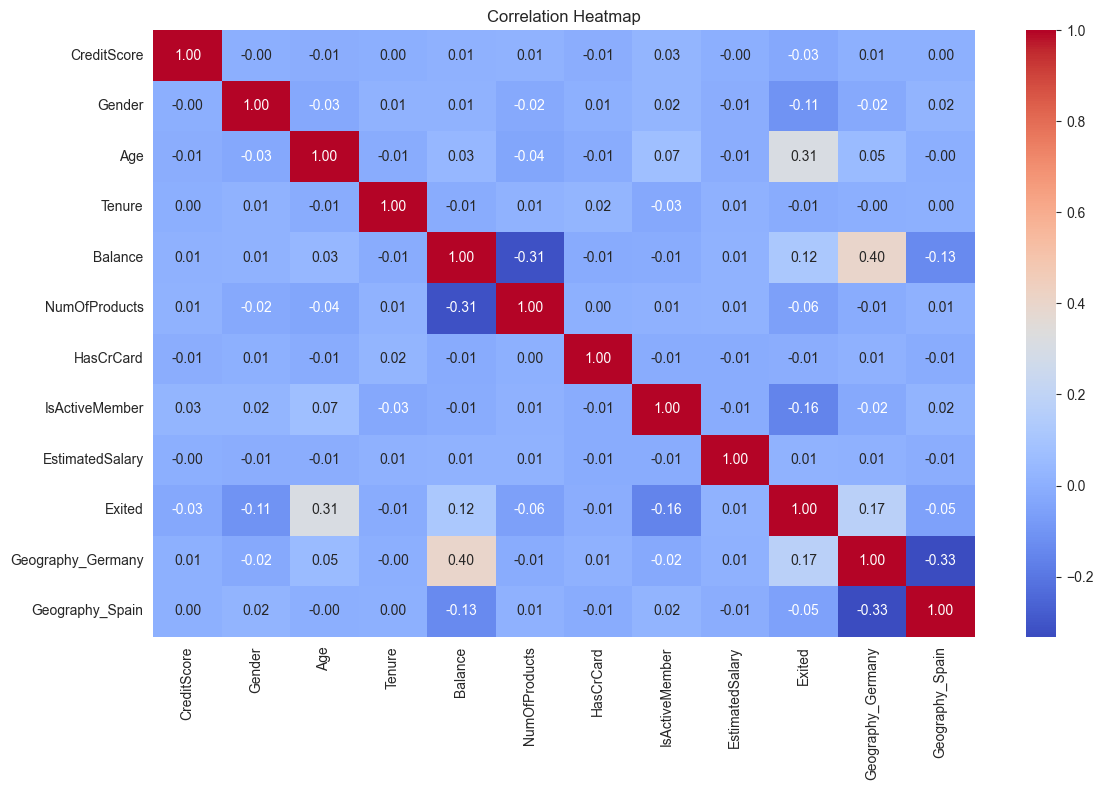

In [22]:
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()

plt.savefig(FIGURES_DIR / "correlation_heatmap.png")

plt.show()

Age                  0.312436
Geography_Germany    0.173488
Balance              0.118533
EstimatedSalary      0.012097
HasCrCard           -0.007138
Tenure              -0.014001
CreditScore         -0.026455
Geography_Spain     -0.052667
NumOfProducts       -0.059196
Gender              -0.106512
IsActiveMember      -0.156128
Name: Exited, dtype: float64

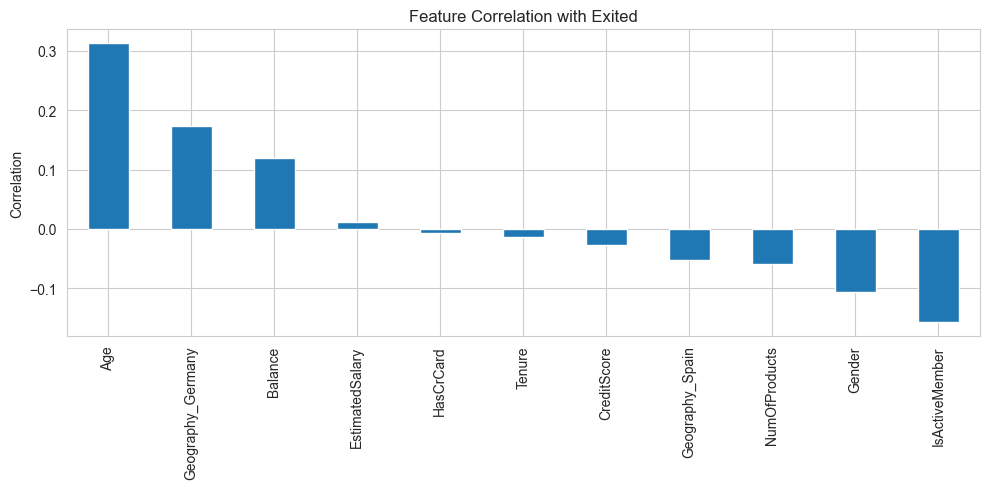

In [23]:
target_corr = correlation_matrix['Exited'].drop('Exited').sort_values(ascending=False)
display(target_corr)

plt.figure(figsize=(10, 5))
target_corr.plot(kind='bar')
plt.title('Feature Correlation with Exited')
plt.ylabel('Correlation')
plt.tight_layout()

plt.savefig(FIGURES_DIR / "feature_correlation_with_exited.png")

plt.show()

## Scale Numerical Features

Scaling is useful especially for:
- Logistic Regression
- SVM

Tree-based models such as Decision Tree and Random Forest do not strictly require scaling, but keeping a scaled version is convenient for your project.


In [24]:
columns_to_scale = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

scaler = StandardScaler()
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,-0.326878,0,0.342615,-1.041760,-1.225848,-0.924827,1,1,0.021886,1,False,False
1,-0.440804,0,0.240011,-1.387538,0.117350,-0.924827,0,1,0.216534,0,False,True
2,-1.538636,0,0.342615,1.032908,1.333053,2.583620,1,0,0.240687,1,False,False
3,0.501675,0,0.034803,-1.387538,-1.225848,0.829397,0,0,-0.108918,0,False,False
4,2.065569,0,0.445219,-1.041760,0.785728,-0.924827,1,1,-0.365276,0,False,True


## Final Processed Dataset Info

In [25]:
print("Final shape:", df.shape)
display(df.head())
display(df.describe())

Final shape: (10000, 12)


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,-0.326878,0,0.342615,-1.041760,-1.225848,-0.924827,1,1,0.021886,1,False,False
1,-0.440804,0,0.240011,-1.387538,0.117350,-0.924827,0,1,0.216534,0,False,True
2,-1.538636,0,0.342615,1.032908,1.333053,2.583620,1,0,0.240687,1,False,False
3,0.501675,0,0.034803,-1.387538,-1.225848,0.829397,0,0,-0.108918,0,False,False
4,2.065569,0,0.445219,-1.041760,0.785728,-0.924827,1,1,-0.365276,0,False,True


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,1.000000e+04,10000.000000,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,10000.00000,10000.000000,1.000000e+04,10000.000000
mean,4.121148e-16,0.545700,-1.918465e-16,-1.103118e-16,-6.536993e-17,1.776357e-16,0.70550,0.515100,-2.522427e-17,0.203700
std,1.000050e+00,0.497932,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,0.45584,0.499797,1.000050e+00,0.402769
min,-2.771109e+00,0.000000,-2.119879e+00,-1.733315e+00,-1.225848e+00,-9.248267e-01,0.00000,0.000000,-1.740268e+00,0.000000
25%,-6.893695e-01,0.000000,-6.834242e-01,-6.959818e-01,-1.225848e+00,-9.248267e-01,0.00000,0.000000,-8.535935e-01,0.000000
50%,1.490049e-02,1.000000,-1.704046e-01,-4.425957e-03,3.319639e-01,-9.248267e-01,1.00000,1.000000,1.802807e-03,0.000000
75%,6.984567e-01,1.000000,5.478228e-01,6.871299e-01,8.199205e-01,8.293969e-01,1.00000,1.000000,8.572431e-01,0.000000
max,2.065569e+00,1.000000,2.394693e+00,1.724464e+00,2.795323e+00,3.460732e+00,1.00000,1.000000,1.737200e+00,1.000000


## Save Processed Dataset

In [26]:
PROCESSED_DIR = BASE_DIR / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

output_path = PROCESSED_DIR / "churn_processed.csv"

df.to_csv(output_path, index=False)
print(f'Processed dataset saved to: {output_path}')

Processed dataset saved to: D:\work\Year - 4\lec\ML\assignment\bank_customer_churn_prediction-ml\data\processed\churn_processed.csv


## Ready for Model Training

You can now use this processed dataset for:
- Logistic Regression
- Decision Tree
- SVM
- Random Forest
